In [1]:
import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

In [2]:
filepath = "data/output_1000_seq3.root"
data = uproot.open(filepath + ":L1BMTFStubSequences").arrays()
df = ak.to_dataframe(data)

In [3]:
df.columns

Index(['nL1BMTFStub', 'L1BMTFStub_hwQual', 'L1BMTFStub_hwPhi',
       'L1BMTFStub_hwPhiB', 'L1BMTFStub_hwEta', 'L1BMTFStub_hwQEta',
       'L1BMTFStub_wheel', 'L1BMTFStub_sector', 'L1BMTFStub_station',
       'orbitNumber', 'bunchCrossing', 'sequenceIndex'],
      dtype='object')

In [4]:
counter = 0

for seq_index, dfs in df.groupby("sequenceIndex"):
    print(f"Sequence: {seq_index}")
    for sector, dfsector in dfs.groupby("L1BMTFStub_sector"):
        print(f'\tSector: {sector}, wheel: {dfsector["L1BMTFStub_wheel"].values}, station: {dfsector["L1BMTFStub_station"].values}, BX: {dfsector["bunchCrossing"].values}')

    if counter > 20:
        break

    counter += 1

Sequence: 0
	Sector: 8, wheel: [-1 -1], station: [1 1], BX: [986 988]
	Sector: 9, wheel: [ 1 -1], station: [1 2], BX: [987 988]
Sequence: 1
	Sector: 2, wheel: [-1 -1 -1], station: [1 1 1], BX: [1164 1165 1166]
	Sector: 3, wheel: [-1 -1], station: [2 4], BX: [1164 1164]
Sequence: 2
	Sector: 9, wheel: [-1 -1 -1 -1], station: [2 1 3 3], BX: [1972 1973 1973 1974]
Sequence: 3
	Sector: 4, wheel: [-2 -2 -2], station: [2 2 2], BX: [2363 2364 2365]
Sequence: 4
	Sector: 8, wheel: [-2  0], station: [2 1], BX: [2673 2674]
	Sector: 10, wheel: [-2], station: [2], BX: [2672]
Sequence: 5
	Sector: 7, wheel: [1 2], station: [1 4], BX: [511 512]
	Sector: 10, wheel: [1], station: [2], BX: [513]
	Sector: 11, wheel: [1], station: [4], BX: [511]
Sequence: 6
	Sector: 8, wheel: [2 1 2], station: [3 1 2], BX: [2700 2700 2700]
	Sector: 11, wheel: [-1 -2 -2], station: [1 2 3], BX: [2701 2702 2702]
Sequence: 7
	Sector: 11, wheel: [-1 -2 -2 -2], station: [1 2 3 3], BX: [2701 2702 2702 2703]
Sequence: 8
	Sector: 1, 

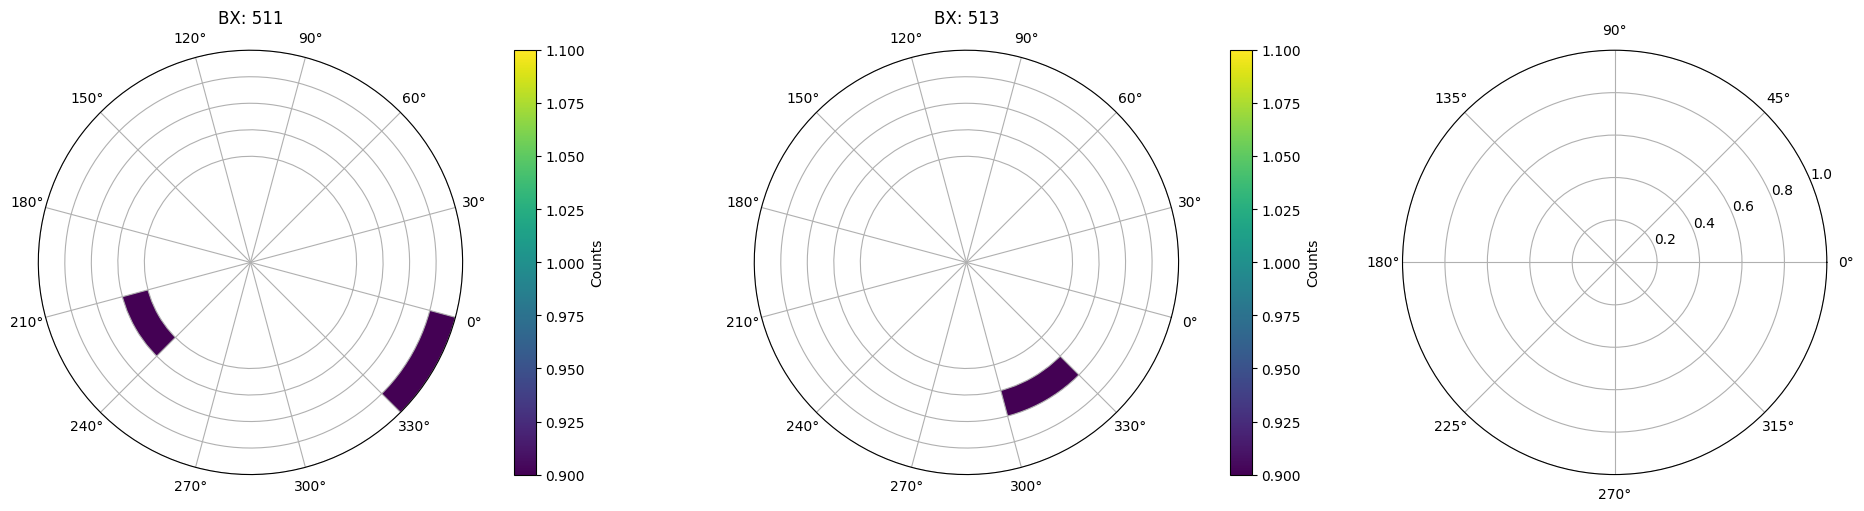

In [9]:
df_grouped = df.groupby("sequenceIndex")
index = 5

dfs = df_grouped.get_group(index)
dfs_grouped = dfs.groupby("L1BMTFStub_wheel")

wheel = 1
dfsw = dfs_grouped.get_group(wheel)

fig, axs = plt.subplots(1, 3, figsize=(20, 5), subplot_kw={"projection": "polar"}, layout="constrained")

for ii, (bx, dfswb) in enumerate(dfsw.groupby("bunchCrossing")):
    axs[ii].set_title(f"BX: {bx}")
    axs[ii].set_thetagrids(range(0, 360, 30))
    axs[ii].set_theta_zero_location("E", -15)
    axs[ii].set_rlim(0, 2)
    axs[ii].set_yticklabels([])
    axs[ii].set_rgrids((0, 1, 1.25, 1.5, 1.75, 2))

    station_counts = {}
    for sector, station in zip(dfswb["L1BMTFStub_sector"].values, dfswb["L1BMTFStub_station"].values):
        sector = sector.item()
        station = station.item()

        if (sector, station) in station_counts:
            station_counts[(sector, station)] += 1

        else:
            station_counts[(sector, station)] = 1

    cmap_fill = cm.viridis
    norm_fill = Normalize(vmin=min(station_counts.values()), vmax=max(station_counts.values()))

    for key in station_counts:
        sector, station = key
        counts = station_counts[key]

        axs[ii].bar(
            x=sector * np.pi/6 + np.pi/12, 
            bottom=1.0 + (station - 1) * 0.25, 
            height=0.25,
            width=np.pi/6, 
            color=cmap_fill(norm_fill(counts))
        )

    sm = cm.ScalarMappable(cmap=cmap_fill, norm=norm_fill)
    sm.set_array([])
    plt.colorbar(sm, ax=axs[ii], orientation="vertical", label="Counts");

In [ ]:
""" Here write a find sequences function
1) fix a wheel (choose the wheel by majority rule among the wheel values present in the specific sequence -> interesting study to do)
2) check presence of ordered station sequences 
"""